Before you submit this assignment, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".

# ES98E Assignment 3 - Linear Regression

## Workshop Aims

- Explore generalised linear regression and Bayesian linear regression
- Experiment with different choices of basis function
- Use the evidence approximation to compare models and select the best one
- Apply Bayesian linear regression to a stress-strain curve from molecular dynamics

**Note**: *The maximum available points for this assignment is 120: 100 points for the core material that everyone is expected to attempt, and 20 points for extension material which is optional, but assessed. The highest percentage you could get on this assignment without attempting the extension material is 100/120 = 83.3%*

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

# Customize default plotting style
%matplotlib inline
import seaborn as sns
sns.set_context('talk')

In [58]:
plt.rcParams["figure.figsize"] = (10, 8)

## Part 1 - Generalised Linear Regression

In the first part of the workshop we will use one of the sample datasets from the lecture, corresponding to observations of a noisy sine function

$$
g(X) = \frac12 + \sin \left( 2\pi X \right) + \epsilon
$$

We also import some functions from the `blr` (Bayesian linear regression) module which implements the basis sets and regression methods demonstrated in Lecture 4.

In [59]:
from blr import (LinearBasis, PolynomialBasis, RadialBasisFunctions,
                 design_matrix, least_squares_MLE, 
                 prior, posterior, posterior_predictive,
                 plot_data, plot_truth, plot_posterior_samples,
                 plot_predictive)

a_0 = -0.3
a_1 = 0.5

def noise(size, variance):
    return np.random.normal(scale=np.sqrt(variance), size=size)

def g(X, noise_variance):
    '''Sinus function plus noise'''
    return 0.5 + np.sin(2 * np.pi * X) + noise(X.shape, noise_variance)

Next, we generate some sample data for $g(X)$, taking care to fix the random number seed so that everyone gets the same data. Take care not to overwrite these variables, or your code might not pass the automated tests!

In [60]:
np.random.seed(42) # set random seed for reproducibility
N_samples = 100
sigma = 0.2

# samples from g(X)
X = np.random.uniform(-1, 1, size=N_samples)[:, None]
Y = g(X, noise_variance=sigma**2)

### Question 1. Least square regression with radial basis functions

**Question 1(a)** Starting from the code given in lectures, experiment with least squares fits using RBFs with different choices of the lengthsale $\ell$ and the number of basis functions $M$ for the sample function $g(x)$ using the data `(X, Y)` generated above. 

Produce a *single* nicely formatted plot containing no more than 9 sub-panels to illustrate your results (take care it is not overwhelming for the viewer).

**Hint** You can't possibly show results for all possible choices of parameters; make a selection which demonstrates the key points.

<div align="right">[10 points plot + 5 points figure caption]</div>


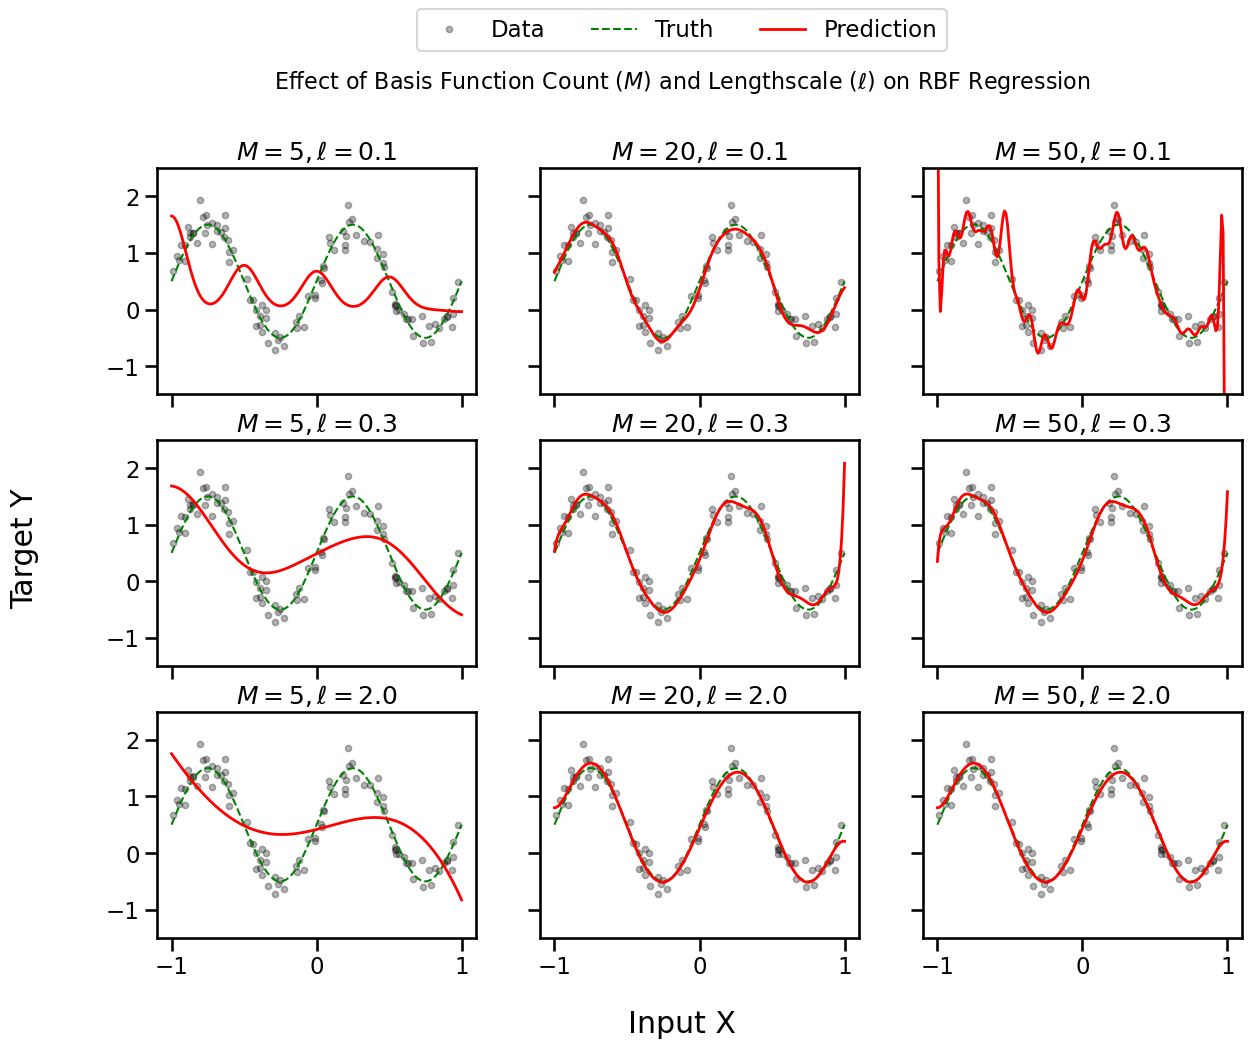

In [61]:
import itertools
varying_l = [0.1, 0.3, 2.0]
Ms = [5, 20, 50]

X_test = np.linspace(-1,1,200)[:, None]
true_y = 0.5 + np.sin(2*np.pi*X_test)

fig, axes = plt.subplots(len(varying_l), len(Ms), figsize=(14, 10), sharex=True, sharey=True)
params = itertools.product(varying_l, Ms)

for ax, (l, M) in zip(axes.flat, params):
    midpoints = np.linspace(-1,1,M)[:, None]
    rbf = RadialBasisFunctions(X=midpoints, ell=l)

    # fit model
    train = design_matrix(X, rbf)
    test = design_matrix(X_test, rbf)
    # compute weights via MLE
    w_MLE, _ = least_squares_MLE(train, Y)
    pred = test @ w_MLE
    # plot graph
    ax.plot(X, Y, 'k.', alpha=0.3, label='Data')
    ax.plot(X_test, true_y, 'g--', lw=1.5, label='Truth')
    ax.plot(X_test, pred, 'r-', lw=2, label='Prediction')
    ax.set_title(rf"$M={M}, \ell={l}$")
    ax.set_ylim(-1.5, 2.5)
    ax.label_outer()


fig.supxlabel("Input X")
fig.supylabel("Target Y")
fig.suptitle(rf"Effect of Basis Function Count ($M$) and Lengthscale ($\ell$) on RBF Regression", fontsize=16)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))

plt.show()

Figure 1:
The grid of plots shows the predictive signal (red) against the data (grey) and true curve (green). Smaller lengthscales $\ell = 0.1$ show more jagged curves due to overfitting, whereas larger lengthscales $\ell = 2.0$ shows smoothing (underfitting).

**Question 1(b)** Write a paragraph (or list of bullet points) to discuss the following points in relation to your exploration in Q1a.

+ When are we underfitting?
+ When are we overfitting?
+ Which combination of parameters gives you the best fit?
+ Without detailed calculations, would a polynomial basis set would be more appropriate than RBFs here?

<div align="right">[10 points]</div>

The model underfits when the model lacks the capacity to track the true function's variations. This occurs when we have a low basis count ($M=5$) since we have an insufficient number of centres to cover the input space, leading to a poor fit regardless of lengthscale. When lengthscale is large ($\ell=2.0$), the basis functions smooth out the sinusoidal features into a nearly flat line, even with high $M$.

The model is overfitting occurs when captures the surrounding noise rather than the true signal. This is most prominent when $M=50$ with $\ell=0.1$. The short lengthscale and high basis count allow the model to spike sharply to interpolate individual noisy data points.

The best fit is $M=20, \ell=0.3$. In this instance, the lengthscale ($\ell=0.3$) roughly matches the periodicity of the sine wave both within the boundaries of the plot but also in the edge cases. The basis function count ($M=20$) is sufficient enough to cover the domain without fitting noise.

A polynomial basis function would not be appropriate in this case: outside of the data range, polynomial functions can travel to $±\infty$, meaning the function would fail to generalise outside of the dataset. In addition, changing the coefficients of a polynomial can affect prediction quality throughout the model, making it difficult to capture variations within data.

## Part 2 - Bayesian Linear Regression

In this section we will focus on fitting the noisy sine curve $g(X)$ using radial basis functions, changing our approach from least squares to Bayesian linear regression. We start from the code provided in the lecture.

### Exploration of Bayesian linear regression

The code given below implements Bayesian linear regression with radial basis functions for the samples `(X, Y)` from $g(x)$. Experiment with different choices for $\alpha, \beta, \ell$ and the number of RBFs $M$.

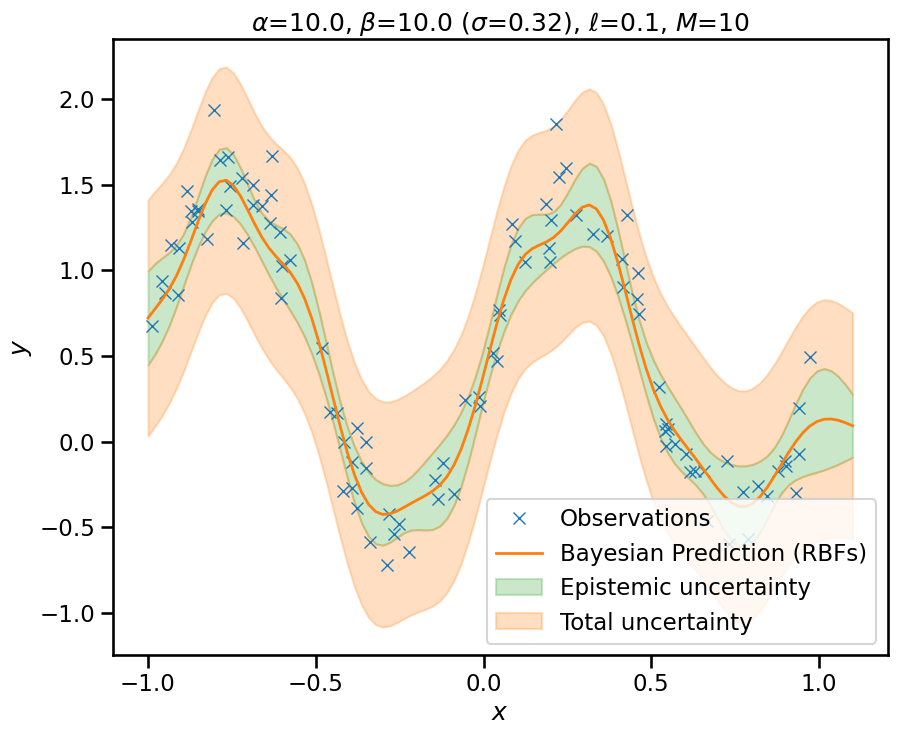

In [62]:
# experiment with changing each of these quantities:
ell = 0.1 # lengthscale hyperparameter
M = 10 # number of basis functions
alpha = 10 # precision for weight prior
beta = 10 # precision for noise model

Xc = np.linspace(1, -1, M)
phi = RadialBasisFunctions(Xc, ell)
Phi = design_matrix(X, phi)

mN, SN = posterior(Phi, Y, alpha, beta)

# evaluate the predictive distribution
X_p = np.linspace(-1, 1.1, 100)[:, None]
Phi_p = design_matrix(X_p, phi)
Y_p, V_ep, V_p = posterior_predictive(Phi_p, mN, SN, beta)

S_p_ep = np.sqrt(V_ep)
S_p = np.sqrt(V_p)
Y_l_ep = Y_p - 2.*S_p_ep  # Lower epistemic predictive bound
Y_u_ep = Y_p + 2.*S_p_ep  # Upper epistemic predictive bound
Y_l = Y_p - 2.*S_p # Lower predictive bound
Y_u = Y_p + 2.*S_p # Upper predictive bound

plt.plot(X, Y, 'x', label='Observations')
plt.plot(X_p, Y_p, lw=2, label='Bayesian Prediction (RBFs)')
plt.fill_between(X_p.flatten(), Y_l_ep, Y_u_ep, color='C2', alpha=0.25, label='Epistemic uncertainty')
plt.fill_between(X_p.flatten(), Y_l, Y_l_ep, color='C1', alpha=0.25, label='Total uncertainty')
plt.fill_between(X_p.flatten(), Y_u_ep, Y_u, color='C1', alpha=0.25)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend(loc='lower right')
plt.title(rf'$\alpha$={alpha:.1f}, $\beta$={beta:.1f} ($\sigma$={1/np.sqrt(beta):.2f}), $\ell$={ell}, $M$={M}');

### Question 2. Evidence Approximation

Recall from the lecture that the log marginal likelihood (aka the evidence) with a Gaussian likelihood of precision $\beta$ and a Gaussian prior on the weights of precision $\alpha$ is given by
$$
\log \mathbb{P}(\mathbf{y}|\alpha, \beta) = \frac{M}{2} \log \alpha + \frac{N}{2} \log \beta - \left[ \frac{\beta}{2} \|\mathbf{y} - \Phi \mathbf{m}_N \|^2 + \frac{\alpha}{2} \mathbf{m}_N^\top \mathbf{m}_N \right] - \frac12 \log|\mathbf{S}_N^{-1}| - \frac{N}{2} \log 2\pi
$$
where $M$ is the number of basis functions and $N$ is the number of observations.

There is a fast algorithm to maximise this evidence with respect to $\alpha$ and $\beta$ - see Chapter 3 of [Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf) for details. Rather than coding it ourselves, we will use the implementation found in [scikit-learn](http://scikit-learn.org).

**Question 2(a)** Adapt the code given below to use [BayesianRidge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.BayesianRidge.html?highlight=bayesianridge#sklearn.linear_model.BayesianRidge) from `sklearn.linear_model` to find the optimal $\alpha$ and $\beta$ for these data. 

*Hint:* After fitting a model named `model` with scikit-learn, the values of these hyperparameters are available as `model.alpha_` and `model.lambda_`; note that scikit-learn uses different names: their `alpha_` is our $\beta$, their `lambda_` is our $\alpha$.

<div align="right">[5 points]</div>

**Note:** In practice you could also use `sklearn` to do the prediction as well as the fitting, with the `BayesianRidge.predict()` method; we don't do that here to make the method more explicit and to allow comparison with the earlier examples.

In [63]:
from sklearn.linear_model import BayesianRidge

ell = 0.1 # lengthscale hyperparameter
Xc = np.linspace(-1, 1, 10)
phi = RadialBasisFunctions(Xc, ell)
Phi = design_matrix(X, phi)

model = BayesianRidge(compute_score=True)
model.fit(Phi, Y.ravel())

beta = model.alpha_
alpha = model.lambda_

print('optimal beta:', beta)
print('optimal alpha:', alpha)

mN, SN = posterior(Phi, Y, alpha, beta)

# evaluate the predictive distribution
X_p = np.linspace(-1, 1.1, 100)[:, None]
Phi_p = design_matrix(X_p, phi)
Y_p, V_ep, V_p = posterior_predictive(Phi_p, mN, SN, beta)

S_p_ep = np.sqrt(V_ep)
S_p = np.sqrt(V_p)

Y_l_ep = Y_p - 2.*S_p_ep  # Lower epistemic predictive bound
Y_u_ep = Y_p + 2.*S_p_ep  # Upper epistemic predictive bound
Y_l = Y_p - 2.*S_p # Lower predictive bound
Y_u = Y_p + 2.*S_p # Upper predictive bound

optimal beta: 26.408607743121152
optimal alpha: 1.7347883321222295


Use the cell below to visualise your results

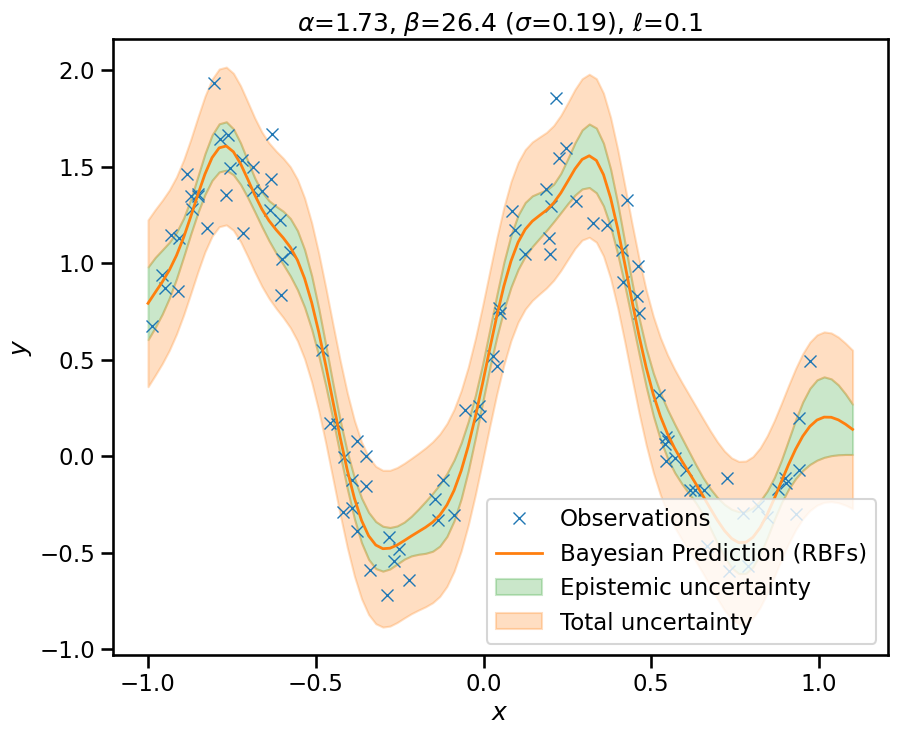

In [64]:
plt.plot(X, Y, 'x', label='Observations')
plt.plot(X_p, Y_p, lw=2, label='Bayesian Prediction (RBFs)')
plt.fill_between(X_p.flatten(), Y_l_ep, Y_u_ep, color='C2', alpha=0.25, label='Epistemic uncertainty')
plt.fill_between(X_p.flatten(), Y_l, Y_l_ep, color='C1', alpha=0.25, label='Total uncertainty')
plt.fill_between(X_p.flatten(), Y_u_ep, Y_u, color='C1', alpha=0.25)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend(loc='lower right')
plt.title(rf'$\alpha$={alpha:.2f}, $\beta$={beta:.1f} ($\sigma$={1/np.sqrt(beta):.2f}), $\ell$={ell}');

In [65]:
assert abs(beta - 26.408) < 1e-2
assert abs(alpha - 1.7347) < 1e-2

**Question 2(b)** Briefly discuss the following points

- Compare your optimised $\beta$ to the actual noise added when generating the data ($\sigma$=0.2)
- Comment on the role played by the optimised $\alpha$

<div align="right">[5 points]</div>

The true value of $\beta$ is given by $$\beta = \frac{1}{\sigma^2}.$$
For the true $\sigma = 0.2$, the theoretical $\beta = \frac{1}{0.2^2} = 25.0.$ Our experimental beta is $\beta_{\mathrm{opt}} \approx 26.41.$ The variables are close in value, showing that evidence approximation is a valid method for recovering properties from noisy data. The optimised $\alpha$ controls the regularisation. For low $\alpha$, weights can become significantly large which can keep a model overfit, whereas the opposite holds for high $\alpha$. High $\alpha$ means significant regularisation, keeping weights near zero, simplifying model complexity (i.e. flatter curves).

**Question 2(c)** Write a function to compute the log of the evidence as a function of the design matrix $\Phi$, the target values $\mathbf{y}$ and the hyperparameters $\alpha$ and $\beta$, using the formula 

$$
\log \mathbb{P}(\mathbf{y}|\alpha, \beta) = \frac{M}{2} \log \alpha + \frac{N}{2} \log \beta - \left[ \frac{\beta}{2} \|\mathbf{y} - \Phi \mathbf{m}_N \|^2 + \frac{\alpha}{2} \mathbf{m}_N^\top \mathbf{m}_N \right]  - \frac12 \log|\mathbf{S}_N^{-1}| - \frac{N}{2} \log 2\pi
$$


**Hints:** 

- you can use the `posterior()` function provided in the `blr` module to compute $\mathbf{m}_N$ and $\mathbf{S}_N^{-1}$ (by passing `return_inverse=True`)
- for numerical stabilty use [np.linalg.slogdet()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.slogdet.html) to compute $\log |\mathbf{S}_N^{-1}|$ rather than explicitly computing the determinant and then taking its logarithm. Note this function returns the sign and the log of the absolute value of the determinant as separate values.

<div align="right">[20 points]</div>

In [66]:
def log_evidence(Phi, y, alpha, beta):
    N, M = Phi.shape
    # N = number of data points, M = number of basis functions

    posterior_mean, _, inv_covar = posterior(Phi, y, alpha, beta, return_inverse=True)
    
    # beta/2 term
    misfit = y - np.dot(Phi, posterior_mean)
    error = (beta / 2.0) * np.sum(misfit ** 2)

    # alpha/2 term
    regularisation = (alpha / 2.0) * np.dot(posterior_mean.T, posterior_mean)

    # 1/2 log |S_N^-1|
    sign, _logdet = np.linalg.slogdet(inv_covar)
    logdet = 0.5 * _logdet

    # constants
    consts = (M / 2.0) * np.log(alpha) + (N / 2.0) * np.log(beta) - (N / 2.0) * np.log(2 * np.pi)

    # final term
    log_evidence = consts - (error + regularisation) - logdet
    return log_evidence

In [67]:
beta = 1 / (0.2 ** 2)
alpha = 0.005

degree = 2
phi = PolynomialBasis(degree)
Phi = design_matrix(X, phi)
assert abs(log_evidence(Phi, Y, alpha, beta) - -482.25713) < 1e-2

degree = 4
phi = PolynomialBasis(degree)
Phi = design_matrix(X, phi)
assert abs(log_evidence(Phi, Y, alpha, beta) - -398.028794) < 1e-2

**Question 2(d)** Use your `log_evidence` function to produce a plot of the evidence for a range of polynomial basis sets with maximum degree varying from 0 to 9 using the noisy sine dataset `(X, Y)`, fixing $\alpha$ and $\beta$ at the values given. 

<div align="right">[10 points]</div>

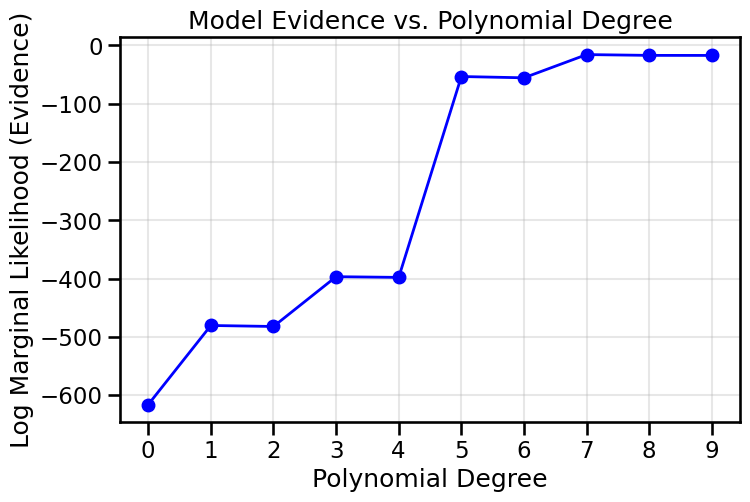

In [68]:
beta = 1 / (0.2 ** 2) # "true" value of noise
alpha = 0.005 # fixed precision for weight prior

degrees = range(10)
log_evidences = []

for degree in degrees:
    poly_basis = PolynomialBasis(degree)
    Phi = design_matrix(X, poly_basis)
    log_ev = log_evidence(Phi, Y, alpha, beta)
    log_evidences.append(log_ev.item())

plt.figure(figsize=(8, 5))
plt.plot(degrees, log_evidences, '-o', linewidth=2, color='b')

plt.xlabel('Polynomial Degree')
plt.ylabel('Log Marginal Likelihood (Evidence)')
plt.title('Model Evidence vs. Polynomial Degree')
plt.xticks(degrees) # Ensure integer ticks on x-axis
plt.grid(True, alpha=0.3)

plt.show()

**Question 2(e)** Which polynomial degree is best supported by the evidence? Why is the marginal likelihood of degree 2 not much larger than that of degree 1? (Think about the functional form used to generate this data)

<div align="right">[10 points]</div>

The best degree polynomial is degree 7: it has the smallest log marginal likelihood with degrees 8 and 9 showing negligible improvement.

The marginal likelihood of degree 2 is not much larger than degree 1. The true function is in the form $$y = 0.5 + \sin(2\pi x).$$ By taking the Maclaurin series expansion of $\sin(x)$, we get the following:

$$ \sin(2\pi x) \approx 2\pi x - \frac{(2\pi x)^3}{3!} + \frac{(2\pi x)^5}{5!} - ...$$

In this expansion, for any even power, the expansion is 0. This is shown in the plot above: for all the even powers, there is a negligible difference in values.

## Extension: Conformal Prediction for Mis-specified Models

Bayesian linear regression assumes that the model can exactly reproduce the data up to additive Gaussian noise. However, this assumption is often violated in practice - the model may be *mis-specified*, meaning it cannot perfectly represent the true underlying function regardless of the parameter values. This is common when fitting computational models to low-noise simulation data.

When the model is mis-specified, Bayesian uncertainty estimates can be unreliable - they may be too narrow (overconfident) because the model attributes all error to aleatoric noise rather than recognising its own limitations. **Conformal prediction** is a distribution-free approach that calibrates prediction intervals to achieve valid coverage guarantees, even when the model is mis-specified.

For further reading, see [Angelopoulos & Bates (2022), "A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification"](https://arxiv.org/abs/2107.07511).

**Split Conformal Prediction Algorithm:**

Given a dataset of input-output pairs and a desired coverage level $1-\zeta$ (e.g., 95%):

1. **Split** the data into a training set $\mathcal{D}_\mathrm{train}$ and a calibration set $\mathcal{D}_\mathrm{calib}$
2. **Fit** the model (including any uncertainty estimates) using only the training set
3. **Compute scores** on the calibration set. For regression with uncertainty estimates $\sigma_i$, use normalised residuals: $s_i = |y_i - \hat{y}_i| / \sigma_i$
4. **Compute the quantile** $\hat{q}$ as the $\lceil (n+1)(1-\zeta) \rceil / n$ quantile of the calibration scores, where $n = |\mathcal{D}_\mathrm{calib}|$

For new predictions, use $\hat{q} \cdot \sigma$ as the calibrated uncertainty. This guarantees that prediction intervals $\hat{y} \pm \hat{q}\sigma$ will achieve at least $1-\zeta$ coverage on future data.

In [69]:
def conformal_calibrate(y_pred, y_std, y_true, coverage=0.95):
    """
    Compute the conformal quantile qhat from calibration data.

    Parameters
    ----------
    y_pred : array
        Predicted values on calibration set
    y_std : array
        Predicted standard deviations (epistemic uncertainty) on calibration set
    y_true : array
        True values on calibration set
    coverage : float
        Desired coverage probability (default 0.95)

    Returns
    -------
    qhat : float
        Conformal quantile for scaling prediction intervals
    """
    zeta = 1.0 - coverage
    scores = np.abs(y_pred - y_true) / y_std
    n = float(len(y_true))
    qhat = np.quantile(scores, np.ceil((n + 1) * (1.0 - zeta)) / n,
                       method='higher')
    return qhat

**Extension Question 1: Conformal Calibration**

Apply conformal prediction to a deliberately mis-specified model: fit a **degree-3 polynomial** to the noisy sine data (which requires degree 7+ for a good fit).

1. Split the data into training (first 70 samples) and calibration (remaining 30 samples) sets
2. Fit using `posterior()` with the training set (use $\alpha=0.005$ and $\beta=1/0.2^2$ as before)
3. Make predictions on the calibration set using `posterior_predictive()` and compute `qhat` using `conformal_calibrate()`
4. Produce a plot comparing the **uncalibrated** epistemic uncertainty with the **conformally-calibrated** uncertainty (scaled by `qhat`)

   **Hint:** Remember that `posterior_predictive()` returns `V_ep` (variance), so use `S_ep = np.sqrt(V_ep)` to get the standard deviation before scaling by `qhat`.

5. Discuss: What value of `qhat` did you obtain? What does this tell you about the Bayesian uncertainties for a mis-specified model?

<div align="right">[5 points code/plot + 5 points discussion]</div>

Qhat: 24.1502


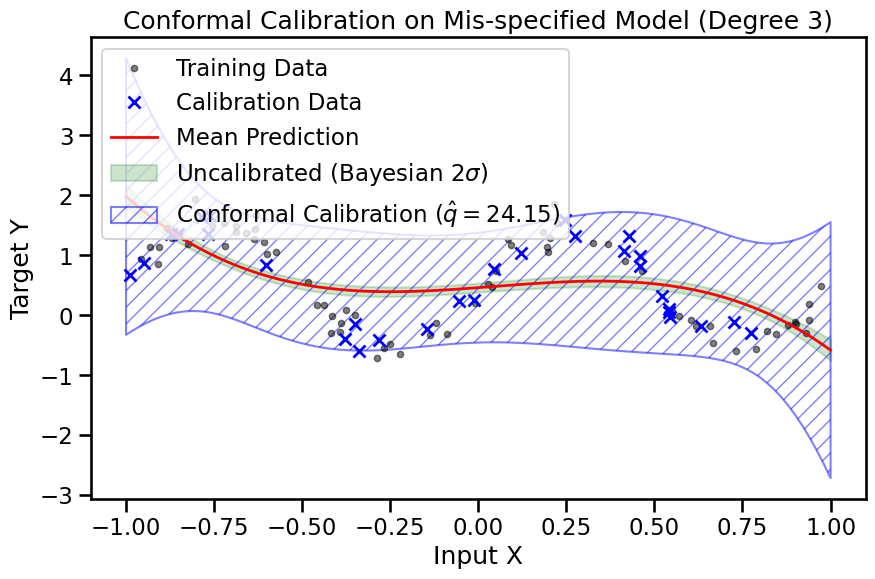

In [70]:
# Split data: training (first 70) and calibration (last 30)
X_train, X_calib = X[:70], X[70:]
Y_train, Y_calib = Y[:70], Y[70:]

# Use degree-3 polynomial (deliberately mis-specified for sin function)
degree = 3
phi = PolynomialBasis(degree)
Phi_train = design_matrix(X_train, phi)
Phi_calib = design_matrix(X_calib, phi)

alpha = 0.005
beta = 1 / (0.2 ** 2)

post_m, post_cov = posterior(Phi_train, Y_train, alpha, beta)

calib_m, calib_var, _ = posterior_predictive(Phi_calib, post_m, post_cov, beta)
calib_stdev = np.sqrt(calib_var) 

qhat = conformal_calibrate(calib_m, calib_stdev, Y_calib.flatten())

print(f"Qhat: {qhat:.4f}")

X_p = np.linspace(-1, 1, 100)[:, None]
Phi_p = design_matrix(X_p, phi)
Y_p, V_ep_p, _ = posterior_predictive(Phi_p, post_m, post_cov, beta)
S_ep_p = np.sqrt(V_ep_p)

# uncalibrated boundaries
lower_uncal = Y_p - 2 * S_ep_p
upper_uncal = Y_p + 2 * S_ep_p

# calibrated boundaries via (qhat * sigma)
lower_cal = Y_p - qhat * S_ep_p
upper_cal = Y_p + qhat * S_ep_p


plt.figure(figsize=(10, 6))
plt.plot(X_train, Y_train, 'k.', label='Training Data', alpha=0.5)
plt.plot(X_calib, Y_calib, 'bx', label='Calibration Data', markeredgewidth=2)

plt.plot(X_p, Y_p, 'r-', lw=2, label='Mean Prediction')

# uncalibrated uncertainty (green)
plt.fill_between(X_p.flatten(), lower_uncal, upper_uncal, color='g', alpha=0.2, 
                 label=r'Uncalibrated (Bayesian 2$\sigma$)')

# calibrated uncertainty (blue)
plt.fill_between(X_p.flatten(), lower_cal, upper_cal, facecolor='none', 
                 edgecolor='b', hatch='//', alpha=0.5, 
                 label=rf'Conformal Calibration ($\hat{{q}}={qhat:.2f}$)')

plt.title(f'Conformal Calibration on Mis-specified Model (Degree {degree})')
plt.xlabel('Input X')
plt.ylabel('Target Y')
plt.legend(loc='upper left')
plt.show()

In [71]:
# Verify qhat value in expected range
assert 15 < qhat < 35, f"qhat={qhat:.1f} is outside expected range"

The calculated value for $\hat{q}$ is 24.1502. This value suggests the Bayesian uncertainty estimates were significantly overconfident. The posterior assumes the degree 3 polynomial basis is correct, minimising the uncertainty aaround the weights of the cubic curve. This is highlighted through the thin uncertainty band around the mean prediction. Conformal calibration uses the residuals from the calibration set, highlighted by the large blue region on the plot. This inflated band visualises the size of the errors: it quantifies how far the cubic assumption deviates from the true shape of the data.

**Optional exploration (not for credit):** Try repeating the above with a degree-7 polynomial (which should fit the sine wave well). You should find that `qhat` is much smaller and the uncalibrated and calibrated uncertainty bands are similar - demonstrating that conformal prediction correctly identifies when the model is well-specified.

Qhat: 6.2459


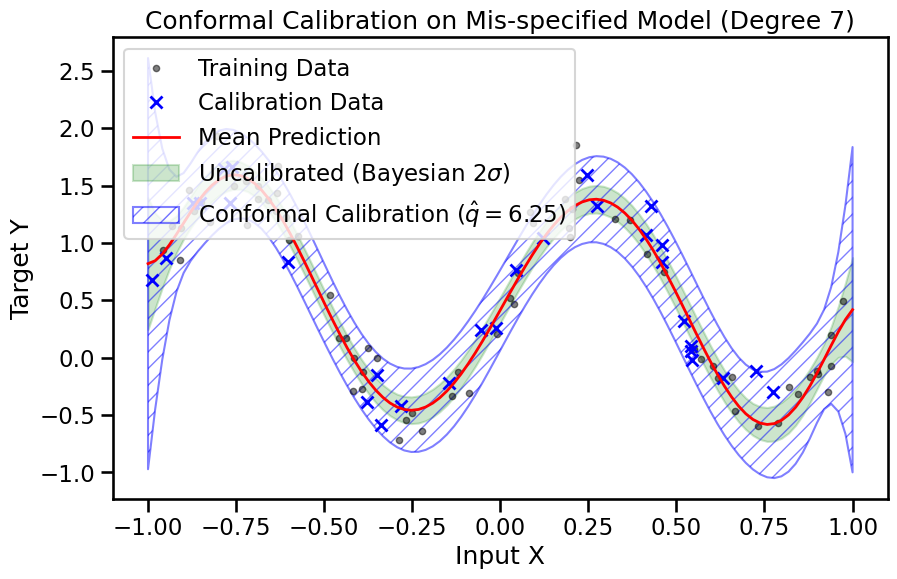

In [72]:
# Split data: training (first 70) and calibration (last 30)
X_train, X_calib = X[:70], X[70:]
Y_train, Y_calib = Y[:70], Y[70:]

# Use degree-3 polynomial (deliberately mis-specified for sin function)
degree = 7
phi = PolynomialBasis(degree)
Phi_train = design_matrix(X_train, phi)
Phi_calib = design_matrix(X_calib, phi)

alpha = 0.005
beta = 1 / (0.2 ** 2)

post_m, post_cov = posterior(Phi_train, Y_train, alpha, beta)

calib_m, calib_var, _ = posterior_predictive(Phi_calib, post_m, post_cov, beta)
calib_stdev = np.sqrt(calib_var) 

qhat = conformal_calibrate(calib_m, calib_stdev, Y_calib.flatten())

print(f"Qhat: {qhat:.4f}")

X_p = np.linspace(-1, 1, 100)[:, None]
Phi_p = design_matrix(X_p, phi)
Y_p, V_ep_p, _ = posterior_predictive(Phi_p, post_m, post_cov, beta)
S_ep_p = np.sqrt(V_ep_p)

# uncalibrated boundaries
lower_uncal = Y_p - 2 * S_ep_p
upper_uncal = Y_p + 2 * S_ep_p

# calibrated boundaries via (qhat * sigma)
lower_cal = Y_p - qhat * S_ep_p
upper_cal = Y_p + qhat * S_ep_p


plt.figure(figsize=(10, 6))
plt.plot(X_train, Y_train, 'k.', label='Training Data', alpha=0.5)
plt.plot(X_calib, Y_calib, 'bx', label='Calibration Data', markeredgewidth=2)

plt.plot(X_p, Y_p, 'r-', lw=2, label='Mean Prediction')

# uncalibrated uncertainty (green)
plt.fill_between(X_p.flatten(), lower_uncal, upper_uncal, color='g', alpha=0.2, 
                 label=r'Uncalibrated (Bayesian 2$\sigma$)')

# calibrated uncertainty (blue)
plt.fill_between(X_p.flatten(), lower_cal, upper_cal, facecolor='none', 
                 edgecolor='b', hatch='//', alpha=0.5, 
                 label=rf'Conformal Calibration ($\hat{{q}}={qhat:.2f}$)')

plt.title(f'Conformal Calibration on Mis-specified Model (Degree {degree})')
plt.xlabel('Input X')
plt.ylabel('Target Y')
plt.legend(loc='upper left')
plt.show()

## Part 3 - Analysing a Molecular Dynamics dataset

We will now obtain some MD data to use for fitting a linear model. We compute the [stress-strain curve](https://en.wikipedia.org/wiki/Stress%E2%80%93strain_curve) for a copper nanowire using an Embedded Atom Model (EAM) interatomic potential as implemented in the [Atomistica](https://github.com/Atomistica/atomistica) code.

We do this by performing a molecular dynamics simulation at a temperature of around 300 K, gradually increasing the strain in the $x$ direction by 0.05% every 100 timesteps. We store the applied strain and computed stress every timestep. We save the resulting arrays to a file, both for reproducibility, and to avoid having the rerun the dynamics.

To save time, the file `stress-strain.txt` is provided, but if you are curious you can look at the code used to generate it.

In [73]:
import os
from atomistica import TabulatedAlloyEAM
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.constraints import UnitCellFilter, FixAtoms
from ase.optimize import BFGSLineSearch
from ase.md import VelocityVerlet
from ase.build import bulk
import ase.units as units

In [74]:
if not os.path.exists('stress-strain.txt'):
    atoms = bulk('Cu', cubic=True) * (10, 2, 2)
    eam_pot = TabulatedAlloyEAM(fn='Cu_mishin1.eam.alloy')
    atoms.set_calculator(eam_pot)    
    
    # open up some vacuum in y- and z-direction to make a nanowire
    atoms.center(5.0, axis=[1, 2]) 

    # optimize the initial unit cell and positions
    opt = BFGSLineSearch(UnitCellFilter(atoms))
    opt.run(fmax=1e-2)
    
    # fix atoms close to the left and right ends
    left  = atoms.positions[:,0].min()
    right = atoms.positions[:,0].max()
    mask = ((np.abs(left  - atoms.positions[:,0]) < 3.0) |
            (np.abs(right - atoms.positions[:,0]) < 3.0))
    print(f'Fixing {mask.sum()} atoms')
    atoms.set_constraint(FixAtoms(mask=mask))    

    np.random.seed(0) # ensure we all get the same results...
    MaxwellBoltzmannDistribution(atoms, 600*units.kB)

    dyn = VelocityVerlet(atoms, 2*units.fs, loginterval=100)
    orig_cell = dyn.atoms.get_cell()

    def print_log(atoms):
        print("t:{0:8.0f} T:{1:8.2f} strain:{2:6.3f} stress:{3:6.3f}".
              format(dyn.get_time()/units.fs, 
              atoms.get_temperature(),
              strains[-1], atoms.get_stress()[0]))
        
    # equilibriate the system for 1000 steps at constant strain
    dyn.run(1000)
    
    strains = [0]
    stresses = [atoms.get_stress()[0]]
    
    def apply_strain(atoms, eps=5e-4):
        strains.append(strains[-1] + eps)
        defm = np.eye(3)
        defm[0,0] += strains[-1]
        atoms.set_cell(orig_cell*defm, scale_atoms=True)
        stresses.append(atoms.get_stress()[0])

    # start loading
    traj = Trajectory('Cu.traj', 'w', atoms)
    dyn.attach(print_log, 100, atoms)    
    dyn.attach(apply_strain, 100, atoms)
    dyn.attach(traj.write, interval=100)
    dyn.run(100000)

    strains = np.array(strains)
    stresses = np.array(stresses) / units.GPa # convert stress to gigapascals
    np.savetxt('stress-strain.txt', np.c_[strains, stresses])
else:
    strains, stresses = np.loadtxt('stress-strain.txt', unpack=True)

We can visualise the trajectory and plot the results (note that the trajectory file is also made available with the Workshop, so you can do this without running the simulation)

In [75]:
from ase.visualize import view
from ase.io.trajectory import Trajectory

traj = Trajectory('Cu.traj')
view(traj, viewer='ngl')

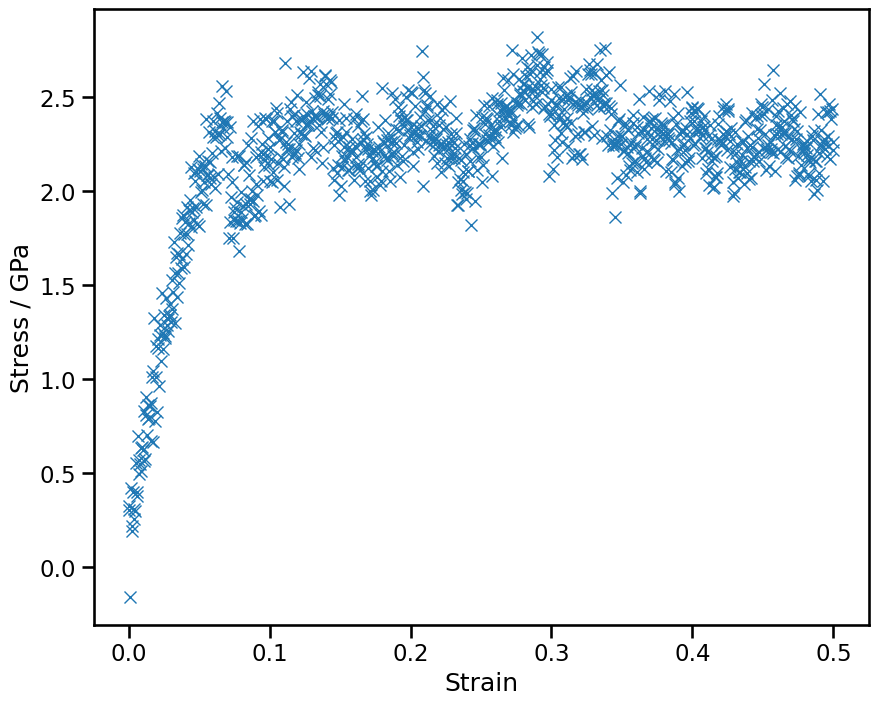

In [76]:
plt.plot(strains, stresses, "x")
plt.xlabel("Strain")
plt.ylabel("Stress / GPa");

### Question 3

As we see from this data, for a ductile material like copper, the stress-strain curve -- an example of a *constitutive relation* -- is initially linear (elastic) followed by a non-linear (plastic) regime. We'd often like to extract information from simulations like this to inform higher-scale models, e.g. finite-element method (FEM). However, the data is very noisy, which makes fitting a simple model to it challenging.

**Question 3(a)** Fit a Bayesian linear regression model to the elastic part of the stress strain data, using the model
$$
\sigma = E \epsilon
$$
where $E$ is the Young's modulus. Produce a plot to visualise the epistemic and aleatoric uncertainty in the elastic part of the stress-strain curve. Use the mask of $\epsilon < 0.06$ provided for the definition of the elastic region.

**Note:** you will have to define a new class of basis functions; neither `LinearBasis` nor `PolynomialBasis` are suitable since we require $\sigma(0) = 0$ and both of those include constant terms. Take care to pass `fit_intercept=False` to the `BayesianRidge` constructor or scikit learn will add an intercept back in again!

<div align="right">[20 points]</div>

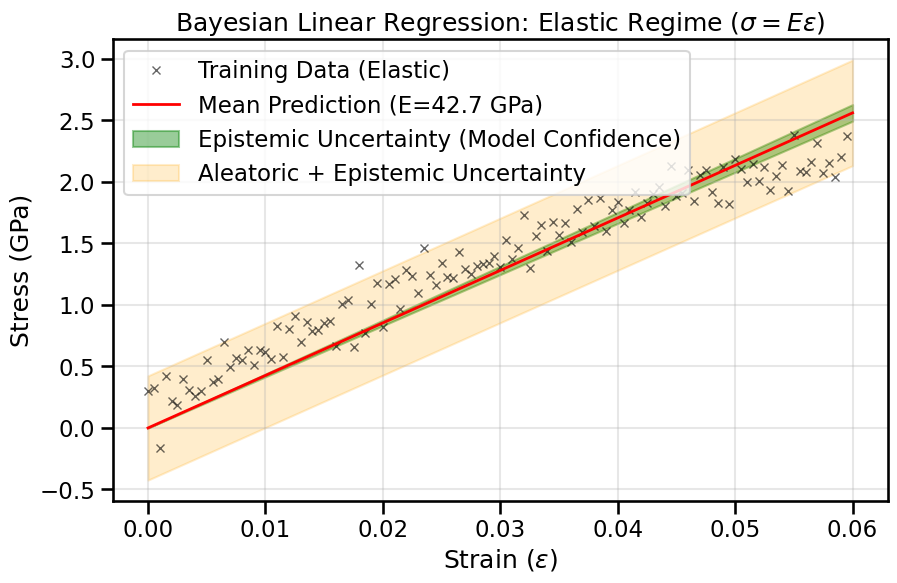

Recovered Young's modulus (E): 42.6797 GPa
Inferred noise standard deviation: 0.2162 GPa


In [77]:
from sklearn.linear_model import BayesianRidge
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the Data (Elastic Region Only)
epsilon_l = 0.06 
elastic = strains < epsilon_l
X = strains[elastic, None]  # Shape (N, 1)
Y = stresses[elastic, None] # Shape (N, 1)

class ProportionalBasis:
    """
    Basis function for a proportional model y = wx.
    """
    def transform(self, X):
        return X
    
    def __call__(self, X):
        return self.transform(X)

basis = ProportionalBasis()
Phi = basis.transform(X)
model = BayesianRidge(fit_intercept=False)
model.fit(Phi, Y.ravel())

X_grid = np.linspace(0, epsilon_l, 100)[:, None]
Phi_grid = basis.transform(X_grid)

y_mean, y_std_total = model.predict(Phi_grid, return_std=True)

sigma_aleatoric = 1.0 / np.sqrt(model.alpha_)
var_epistemic = np.maximum(0, y_std_total**2 - sigma_aleatoric**2)
sigma_epistemic = np.sqrt(var_epistemic)

# 5. Plotting
plt.figure(figsize=(10, 6))
plt.plot(X, Y, 'kx', alpha=0.6, label='Training Data (Elastic)', markersize=6)
plt.plot(X_grid, y_mean, 'r-', linewidth=2, label=f'Mean Prediction (E={model.coef_[0]:.1f} GPa)')

# plot epistemic uncertainty - inner band = confidence
plt.fill_between(
    X_grid.ravel(), 
    y_mean - 1.96 * sigma_epistemic, 
    y_mean + 1.96 * sigma_epistemic, 
    color='green', alpha=0.4, 
    label='Epistemic Uncertainty (Model Confidence)'
)

# plot total uncertainty - outer band = prediction interval
plt.fill_between(
    X_grid.ravel(), 
    y_mean - 1.96 * y_std_total, 
    y_mean + 1.96 * y_std_total, 
    color='orange', alpha=0.2, 
    label='Aleatoric + Epistemic Uncertainty'
)

plt.xlabel(rf'Strain ($\epsilon$)')
plt.ylabel('Stress (GPa)')
plt.title(rf'Bayesian Linear Regression: Elastic Regime ($\sigma = E\epsilon$)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

print(f"Recovered Young's modulus (E): {model.coef_[0]:.4f} GPa")
print(f"Inferred noise standard deviation: {sigma_aleatoric:.4f} GPa")

**Question 3(b)** Compute the posterior distribution of the Young's modulus $E$ given the data from your results. Store the mean in a variable `E_mean` and the standard deviation in a variable `E_std`.

*Note:* Use the posterior mean `mN` and covariance matrix `SN` from your answer to Q3(a).

<div align="right">[5 points]</div>

In [78]:
E_mean = model.coef_[0] # only one feature so the first coeff. is E
E_std = np.sqrt(model.sigma_[0, 0])

print(f"Posterior Distribution for Young's Modulus E:")
print(f"E_mean: {E_mean:.4f} GPa")
print(f"E_std: {E_std:.4f} GPa")

Posterior Distribution for Young's Modulus E:
E_mean: 42.6797 GPa
E_std: 0.5732 GPa


In [79]:
assert abs(E_mean - 42.680) < 0.01
assert abs(E_std - 0.5732) < 0.01

**Extension Question 2**

Extend your model to fit the full stress-strain curve. You can use any basis functions you like in the non-linear regime, but ensure it has a well-defined elastic regime. Visualise the epistemic and aleatoric uncertainty in the full stress-strain curve. [10 points]

**Hint:** You can use a Heaviside function to switch on or off different components of your model depending on the strain, e.g. for a model which is linear below the value $\epsilon_l$ and non-linear above it you could use

$$
f(\epsilon) = E\epsilon \left[1 - H(\epsilon - \epsilon_l)\right] + g(\epsilon;\mathbf{w}_g)H(\epsilon - \epsilon_l),
$$
where
$$
H(x) = \begin{cases}
0,\;\text{if}\;x < 0\\
1,\;\text{otherwise}.
\end{cases}
$$
and $g(\epsilon; \mathbf{w}_g)$ is some non-linear function parameterised by the vector of weights $\mathbf{w}_g$.
The Heaviside function is implemented in the `np.heaviside()` function.

<div align="right">[10 points]</div>

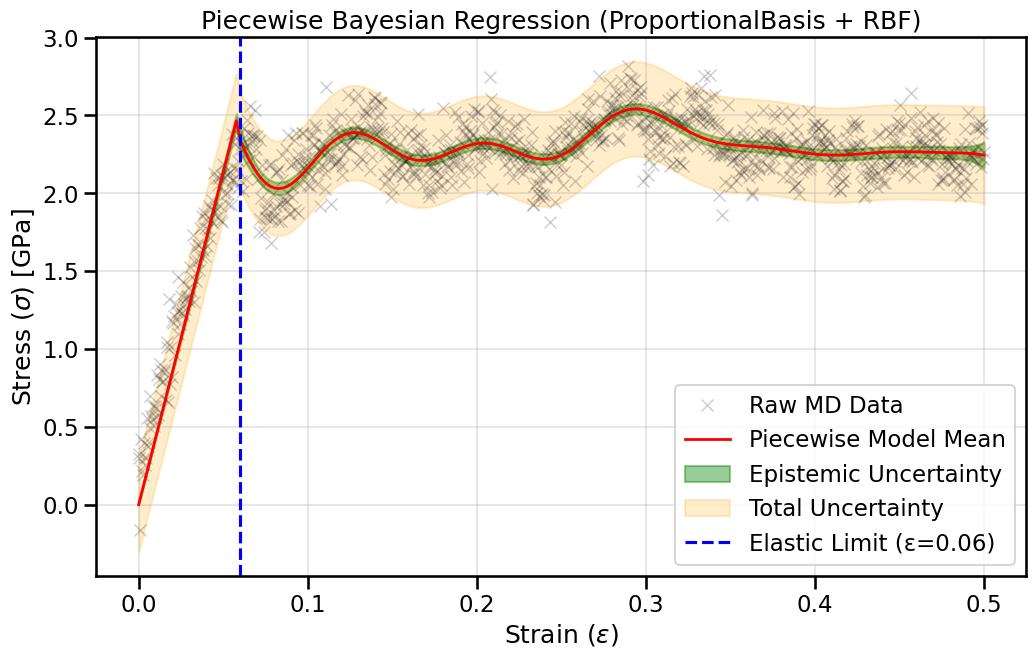

In [80]:
"""
Extension Question 2: Piecewise Bayesian Regression for Stress-Strain Analysis

The stress-strain relationship is modeled as a piecewise function:
    
    σ(ε) = f_elastic(ε) * H(ε_l - ε) + f_plastic(ε) * H(ε - ε_l)

Where:
  - ε_l is the elastic limit (strain = 0.06).
  - H(x) is the Heaviside step function (1 if x >= 0, else 0).

For ε < 0.06:
   - Modeled using the ProportionalBasis: f(ε) = Eε
   - We enforce an intercept of 0 (fit_intercept=False) to satisfy σ(0) = 0.
   - The learned weight corresponds directly to Young's Modulus (E).

For ε >= 0.06:
   - Modeled using Radial Basis Functions (RBFs): f(ε) = sum(w_i * psi_i(ε)
   - Captures nonlinearity, so it is separate from the elastic segment


Two separate design matrices are used or the two bases: binary masks are used to only apply features in their respective bases, and then flatten and fit it to a BayesianRidge model
"""

epsilon_l = 0.06
n_rbf = 15
rbf_width = 0.05

X_full = strains[:, None]
Y_full = stresses[:, None]

Phi_linear = X_full 

# distribute centers covering the plastic range (0.06 to 0.5)
centers = np.linspace(epsilon_l, 0.5, n_rbf)[:, None]
rbf_basis = RadialBasisFunctions(centers, rbf_width)
Phi_rbf = design_matrix(X_full, rbf_basis)

# heaviside masking
mask_elastic = (X_full < epsilon_l).astype(float)
mask_plastic = (X_full >= epsilon_l).astype(float)

# apply masks
Phi_elastic_masked = Phi_linear * mask_elastic
Phi_plastic_masked = Phi_rbf * mask_plastic

# Stack features: [Elastic_Term | RBF_1, RBF_2, ... RBF_N]
Phi_combined = np.hstack([Phi_elastic_masked, Phi_plastic_masked])

# ensure it passes through origin via fit_intercept=False
model_ext = BayesianRidge(fit_intercept=False)
model_ext.fit(Phi_combined, Y_full.ravel())


X_grid = np.linspace(0, 0.5, 200)[:, None]
mask_e_grid = (X_grid < epsilon_l).astype(float)
mask_p_grid = (X_grid >= epsilon_l).astype(float)
Phi_lin_grid = X_grid
Phi_rbf_grid = design_matrix(X_grid, rbf_basis)
Phi_grid_final = np.hstack([Phi_lin_grid * mask_e_grid, Phi_rbf_grid * mask_p_grid])

y_mean, y_std_total = model_ext.predict(Phi_grid_final, return_std=True)

sigma_aleatoric = 1.0 / np.sqrt(model_ext.alpha_)
var_epistemic = np.maximum(0, y_std_total**2 - sigma_aleatoric**2)
sigma_epistemic = np.sqrt(var_epistemic)

plt.figure(figsize=(12, 7))
plt.plot(strains, stresses, 'kx', alpha=0.2, label='Raw MD Data')
plt.plot(X_grid, y_mean, 'r-', lw=2, label='Piecewise Model Mean')

plt.fill_between(
    X_grid.ravel(), 
    y_mean - 1.96 * sigma_epistemic, 
    y_mean + 1.96 * sigma_epistemic, 
    color='green', alpha=0.4, 
    label='Epistemic Uncertainty'
)

plt.fill_between(
    X_grid.ravel(), 
    y_mean - 1.96 * y_std_total, 
    y_mean + 1.96 * y_std_total, 
    color='orange', alpha=0.2, 
    label='Total Uncertainty'
)

# line at elastic limit to signify change from elastic to plastic
plt.axvline(epsilon_l, color='b', linestyle='--', label=f'Elastic Limit (ε={epsilon_l})')

plt.xlabel(rf'Strain ($\epsilon$)')
plt.ylabel(rf'Stress ($\sigma$) [GPa]')
plt.title('Piecewise Bayesian Regression (ProportionalBasis + RBF)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

**Extension Question 3 [Not for Credit]**

Use your model to obtain a probabilistic estimate for the peak of the stress-strain curve (the *ultimate tensile stress*) - note that this is not easy (or even necessarily possible) to obtain analytically, but once you have the posterior distribution of the weights it's cheap to draw sample models.

<div align="right">[Not for credit]</div>

In [81]:
# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 

**Extension Question 4 [Not for Credit]**

Adapt your answer to Extension Question 2 to ensure the fitted function does not have a discontinuity at the transition between the elastic and inelastic regime. Can you reparameterise so that the function and its first derivative are both continuous at this point?

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()